In [2]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib notebook
%matplotlib inline
%matplotlib ipympl
import seaborn as sns
import ipywidgets as widgets
import plotly.express as px
import plotly.graph_objects as go

In [3]:
per_game = pd.read_csv("nba_team_per_game_2021_2025.csv")
advanced = pd.read_csv("nba_team_advanced_2021_2025.csv")
nba = per_game.merge(advanced, on=["Team","Season"])
nba["W_pct"] = nba["W"] / (nba["W"] + nba["L"])

In [4]:
nba.head()
nba.info()
nba.describe()

,Season,Team,G,MP,FG,FGA,FG%,3P,3PA,3P%,...,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,Arena,Attend.,Attend./G,W_pct
0,2024-25,Atlanta Hawks,82.0,241.2,43.4,91.8,0.472,13.5,37.7,0.358,...,0.410,0.579,0.546,13.2,26.3,0.196,State Farm Arena,657613.0,16440.0,0.487805
1,2024-25,Boston Celtics,82.0,241.8,41.6,90.0,0.462,17.8,48.2,0.368,...,0.536,0.591,0.561,10.8,25.7,0.169,TD Garden,785396.0,19156.0,0.743902
2,2024-25,Brooklyn Nets,82.0,241.2,37.6,86.1,0.437,13.6,39.4,0.344,...,0.458,0.552,0.516,13.7,24.5,0.189,Barclays Center,713304.0,17398.0,0.317073
3,2024-25,Charlotte Hornets,82.0,240.9,38.3,89.1,0.430,13.0,38.3,0.339,...,0.430,0.537,0.503,13.7,26.5,0.174,Spectrum Center,703935.0,17169.0,0.231707
4,2024-25,Chicago Bulls,82.0,240.9,43.2,92.0,0.470,15.4,42.0,0.367,...,0.457,0.585,0.553,12.7,22.3,0.173,United Center,825659.0,20138.0,0.475610


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 48 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Season     150 non-null    object 
 1   Team       150 non-null    object 
 2   G          150 non-null    float64
 3   MP         150 non-null    float64
 4   FG         150 non-null    float64
 5   FGA        150 non-null    float64
 6   FG%        150 non-null    float64
 7   3P         150 non-null    float64
 8   3PA        150 non-null    float64
 9   3P%        150 non-null    float64
 10  2P         150 non-null    float64
 11  2PA        150 non-null    float64
 12  2P%        150 non-null    float64
 13  FT         150 non-null    float64
 14  FTA        150 non-null    float64
 15  FT%        150 non-null    float64
 16  ORB        150 non-null    float64
 17  DRB        150 non-null    float64
 18  TRB        150 non-null    float64
 19  AST        150 non-null    float64
 20  STL       

,G,MP,FG,FGA,FG%,3P,3PA,3P%,2P,2PA,...,FTr,3PAr,TS%,eFG%,TOV%,ORB%,FT/FGA,Attend.,Attend./G,W_pct
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.00000,150.000000,150.000000,150.000000,150.000000,...,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,146.000000,146.000000,150.000000
mean,81.131333,240.111333,41.854667,87.991167,0.533693,12.89800,35.152340,0.578733,28.964000,52.837553,...,0.249947,0.399040,0.575120,0.540933,12.397333,23.754000,0.194867,612362.431507,14962.575342,0.500000
std,13.779399,16.204501,4.389533,7.542130,0.794715,1.97693,4.502022,2.665000,3.418981,5.711461,...,0.020993,0.038988,0.018437,0.019094,0.905683,2.522905,0.016706,266123.118742,6421.038578,0.144619
min,72.000000,43.200000,37.600000,0.475000,0.429000,9.90000,0.351000,0.318000,23.900000,0.533000,...,0.197000,0.314000,0.527000,0.490000,9.900000,17.900000,0.156000,5817.000000,162.000000,0.170732
25%,82.000000,240.900000,40.500000,86.825000,0.459000,11.72500,32.600000,0.349250,27.325000,50.400000,...,0.235000,0.371250,0.563000,0.529000,11.800000,21.900000,0.181000,642867.750000,15600.750000,0.414634
50%,82.000000,241.500000,41.600000,88.600000,0.469000,12.70000,35.150000,0.363500,28.850000,53.450000,...,0.248000,0.394000,0.577000,0.541000,12.400000,23.600000,0.194500,715500.000000,17444.000000,0.526084
75%,82.000000,242.025000,42.875000,90.100000,0.480000,13.70000,37.700000,0.373750,30.275000,55.725000,...,0.262500,0.425000,0.588750,0.556000,13.000000,25.175000,0.205750,768336.250000,18740.250000,0.597561
max,241.700000,243.700000,90.900000,94.400000,10.200000,29.00000,48.200000,33.000000,61.900000,62.100000,...,0.300000,0.536000,0.610000,0.578000,14.900000,31.700000,0.250000,856148.000000,20882.000000,0.829268


In [8]:
target = "W_pct"
nba_num = nba.select_dtypes(include=[np.number])
drop_like = nba_num.columns[nba_num.columns.str.match(r"^(W($|_)|L($|_))")].tolist()
predictors = nba_num.drop(columns=list(set(drop_like + [target])), errors="ignore")
non_offense_cols = [
    "NRtg",
    "ORtg",
    "DRtg",
    "MOV",
    "SRS",
    "Age",
    "PW",
    "PL",
    "MP",
    "SOS",
    "Attend.", "Attend./G"]
predictors = predictors.drop(columns=non_offense_cols, errors="ignore")
y = nba_num[target]
predictors.shape

(150, 30)

In [9]:
corr_pred = pd.concat([predictors, nba_num[[target]]], axis=1).corr()
win_corr = corr_pred[target].drop(target).sort_values(ascending=False)
win_corr.head(20)

TS%       0.705123
eFG%      0.700162
PTS       0.598510
DRB       0.343608
3P        0.259693
TRB       0.216125
AST       0.205588
FG        0.186016
STL       0.155927
FT/FGA    0.121140
3PAr      0.119635
FT        0.105921
3PA       0.096699
2P        0.088303
BLK       0.065557
ORB%      0.055209
FTA       0.008096
FGA       0.006813
FTr       0.004009
FG%      -0.002838
Name: W_pct, dtype: float64

<Figure size 600x1000 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Offensive Metric Correlation with Win %')

Text(45.722222222222214, 0.5, '')

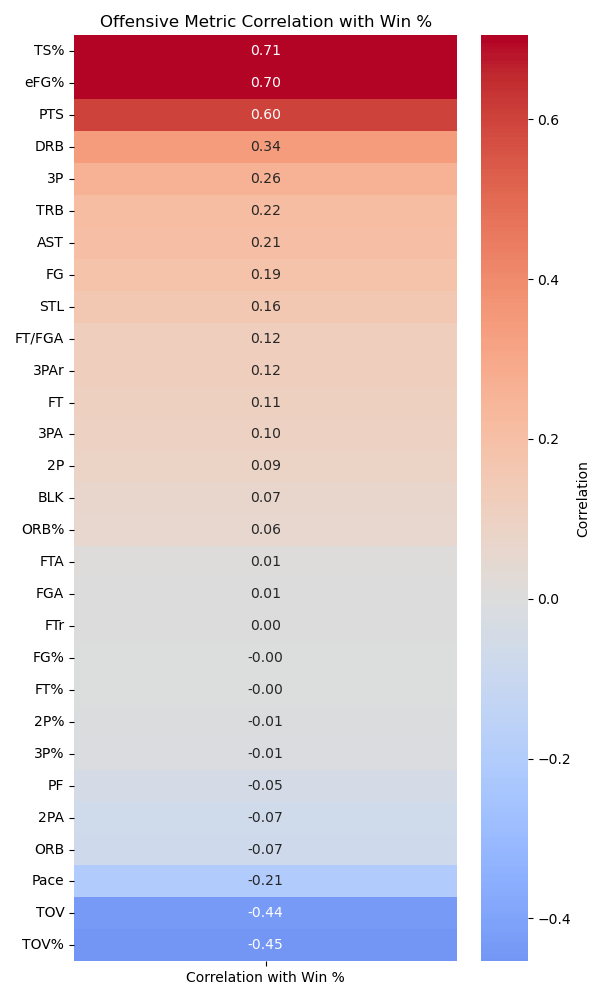

In [15]:
exclude_cols = ["G", "MP"]
win_corr_clean = win_corr.drop(labels=exclude_cols, errors="ignore")
top15 = win_corr_clean.sort_values(ascending=False).head(15)
bottom15_raw = win_corr_clean.sort_values(ascending=True).head(14)
bottom15 = bottom15_raw.sort_values(ascending=False)
ordered_stats = list(top15.index) + list(bottom15.index)
win_corr_30 = win_corr_clean.loc[ordered_stats].to_frame(name="Correlation with Win %")
plt.figure(figsize=(6,10))
sns.heatmap(
    win_corr_30,
    cmap="coolwarm",
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={"label": "Correlation"})
plt.title("Offensive Metric Correlation with Win %")
plt.ylabel("")
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Top 10 Offensive Stats Correlated with Win %')

Text(0.5, 0, 'Correlation with Win %')

Text(0, 0.5, 'Offensive Stat')

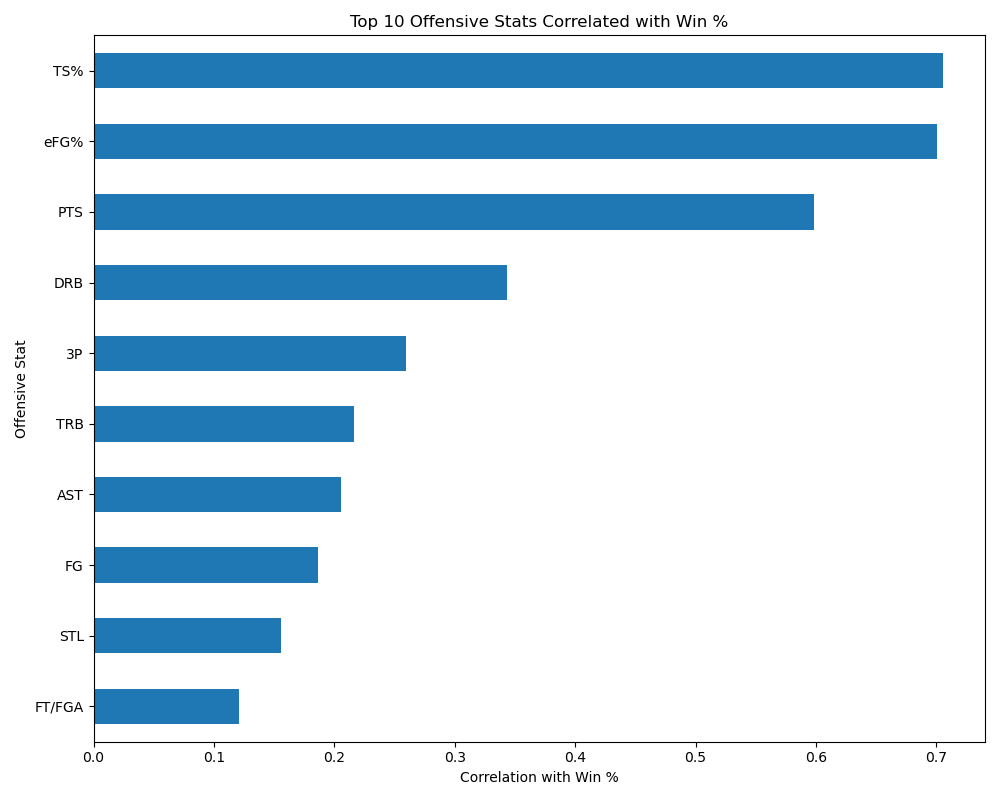

In [12]:
top_corr = win_corr.head(10)
plt.figure(figsize=(10,8))
top_corr.sort_values().plot(kind="barh")
plt.title("Top 10 Offensive Stats Correlated with Win %")
plt.xlabel("Correlation with Win %")
plt.ylabel("Offensive Stat")
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Bottom 10 Offensive Stats Correlated with Win %')

Text(0.5, 0, 'Correlation with Win %')

Text(0, 0.5, 'Offensive Stat')

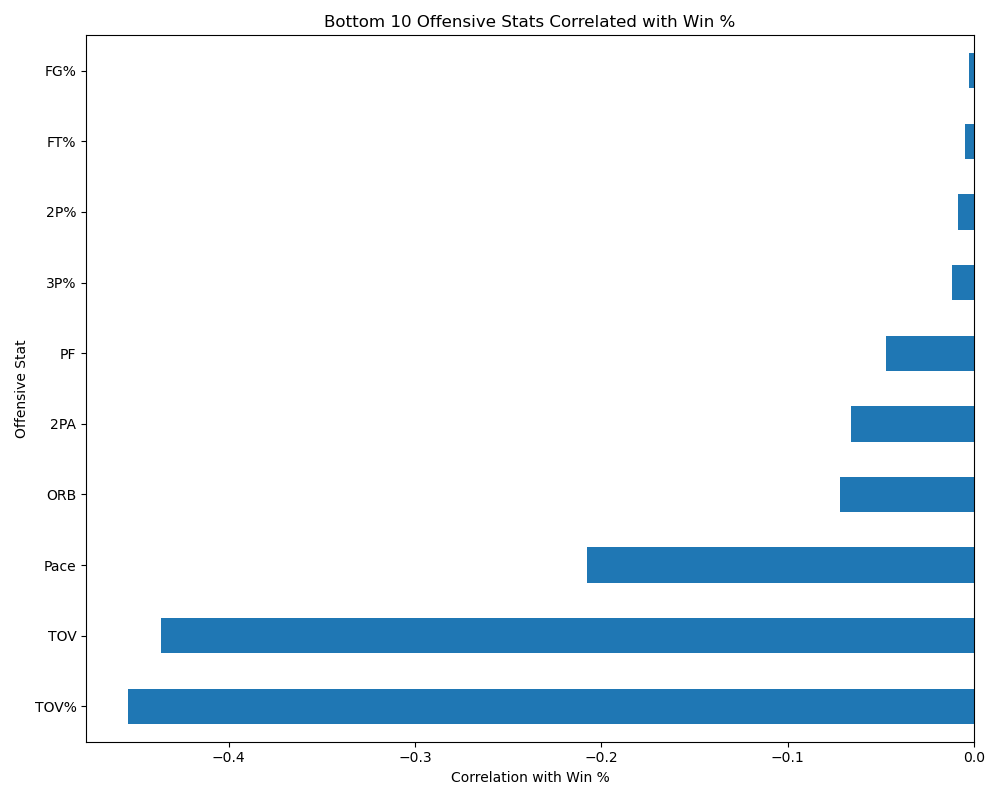

In [19]:
bottom_corr = win_corr.drop("G").tail(10)
plt.figure(figsize=(10,8))
bottom_corr.sort_values().plot(kind="barh")
plt.title("Bottom 10 Offensive Stats Correlated with Win %")
plt.xlabel("Correlation with Win %")
plt.ylabel("Offensive Stat")
plt.tight_layout()
plt.show()

<Axes: >

Text(0.5, 1.0, 'Top 10 Positive Correlations')

Text(0.5, 0, 'Correlation with Win %')

Text(0, 0.5, '')

<Axes: >

Text(0.5, 1.0, 'Top 10 Negative Correlations')

Text(0.5, 0, 'Correlation with Win %')

Text(0, 0.5, '')

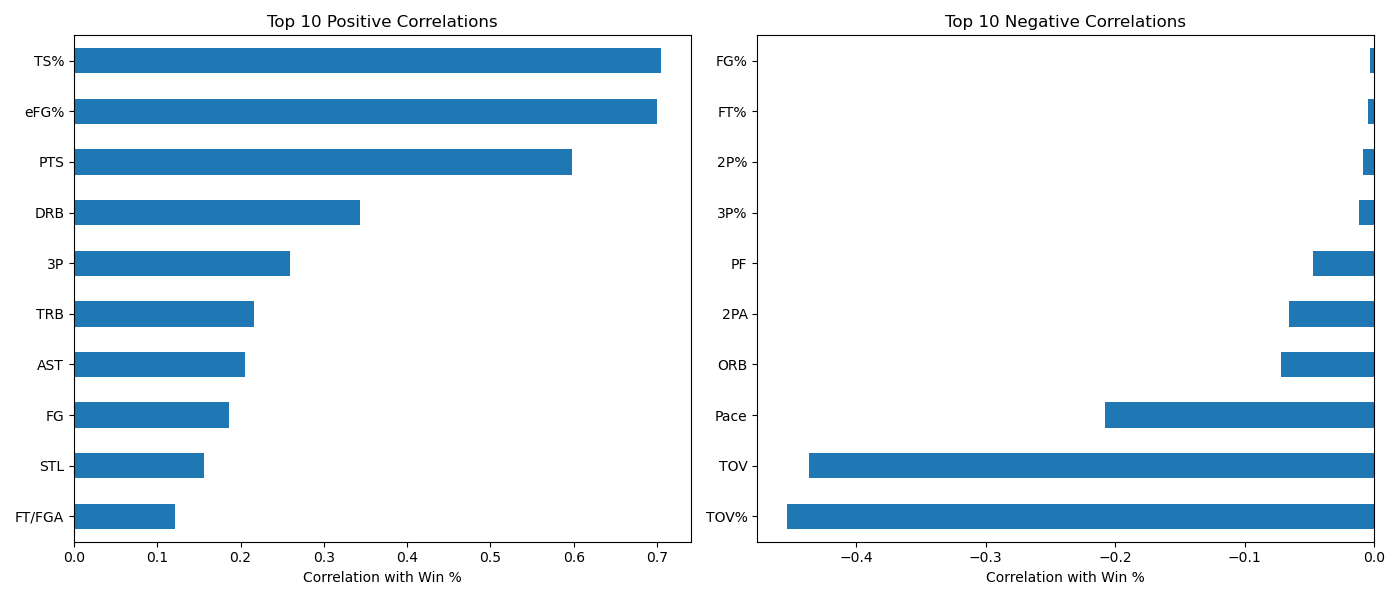

In [21]:
top_corr = win_corr.head(10)
bottom_corr = win_corr.drop("G").tail(10)
fig, axes = plt.subplots(1, 2, figsize=(14,6))
top_corr.sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Top 10 Positive Correlations")
axes[0].set_xlabel("Correlation with Win %")
axes[0].set_ylabel("")
bottom_corr.sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Top 10 Negative Correlations")
axes[1].set_xlabel("Correlation with Win %")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()

In [32]:
per_path = "nba_team_per_game_2021_2025.csv"
adv_path = "nba_team_advanced_2021_2025.csv"
per = pd.read_csv(per_path)
adv = pd.read_csv(adv_path)
nba = per.merge(adv, on=["Season", "Team"], how="inner")
nba["W_pct"] = nba["W"] / (nba["W"] + nba["L"])
OFF_METRICS = {
    "ORtg": True,
    "TS%": True,
    "eFG%": True,
    "ORB%": True,
    "FT/FGA": True,
    "3PAr": True,
    "TOV%": False}
DEF_METRICS = {
    "DRtg": False}
def rank_metric(series: pd.Series, higher_better: bool) -> pd.Series:
    return series.rank(ascending=not higher_better, method="min")
season_df = nba.copy()
for col, higher_better in OFF_METRICS.items():
    season_df[f"rk_{col}"] = season_df.groupby("Season")[col].transform(
        lambda s: rank_metric(s, higher_better))
for col, higher_better in DEF_METRICS.items():
    season_df[f"rk_{col}"] = season_df.groupby("Season")[col].transform(
        lambda s: rank_metric(s, higher_better))
season_df["Off_Borda_Score"] = season_df[[f"rk_{c}" for c in OFF_METRICS]].mean(axis=1)
season_df["Def_Borda_Score"] = season_df[[f"rk_{c}" for c in DEF_METRICS]].mean(axis=1)
season_df["Combined_Borda_Score"] = season_df[["Off_Borda_Score", "Def_Borda_Score"]].mean(axis=1)
nba_cross = season_df.groupby("Team").agg(
    Seasons_Played=("Season", "nunique"),
    Avg_W_pct=("W_pct", "mean"),
    Avg_Combined_Borda=("Combined_Borda_Score", "mean"),
    Combined_Borda_StdDev=("Combined_Borda_Score", "std"),).reset_index()
nba_cross["Avg_W_pct"] = nba_cross["Avg_W_pct"] * 100
nba_cross["Combined_Borda_StdDev"] = nba_cross["Combined_Borda_StdDev"].fillna(0)
nba_cross["Overall_Combined_Rank"] = nba_cross["Avg_Combined_Borda"].rank(
    ascending=True, method="min").astype(int)
nba_cross["Consistency_Rank"] = nba_cross["Combined_Borda_StdDev"].replace(0, np.nan).rank(
    ascending=True, method="min", na_option="bottom").astype(int)
df = nba_cross.rename(columns={"Team": "Tm"})
df.head()

,Tm,Seasons_Played,Avg_W_pct,Avg_Combined_Borda,Combined_Borda_StdDev,Overall_Combined_Rank,Consistency_Rank
0,Atlanta Hawks,5,50.413279,17.471429,1.663381,22,2
1,Boston Celtics,5,66.829268,7.342857,3.702729,1,15
2,Brooklyn Nets,5,49.186992,16.685714,2.890255,20,6
3,Charlotte Hornets,5,35.995935,21.471429,4.070990,29,18
4,Chicago Bulls,5,48.611111,16.442857,2.917837,17,7


Fetching team logos and loading visualization...


(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

0

0

0

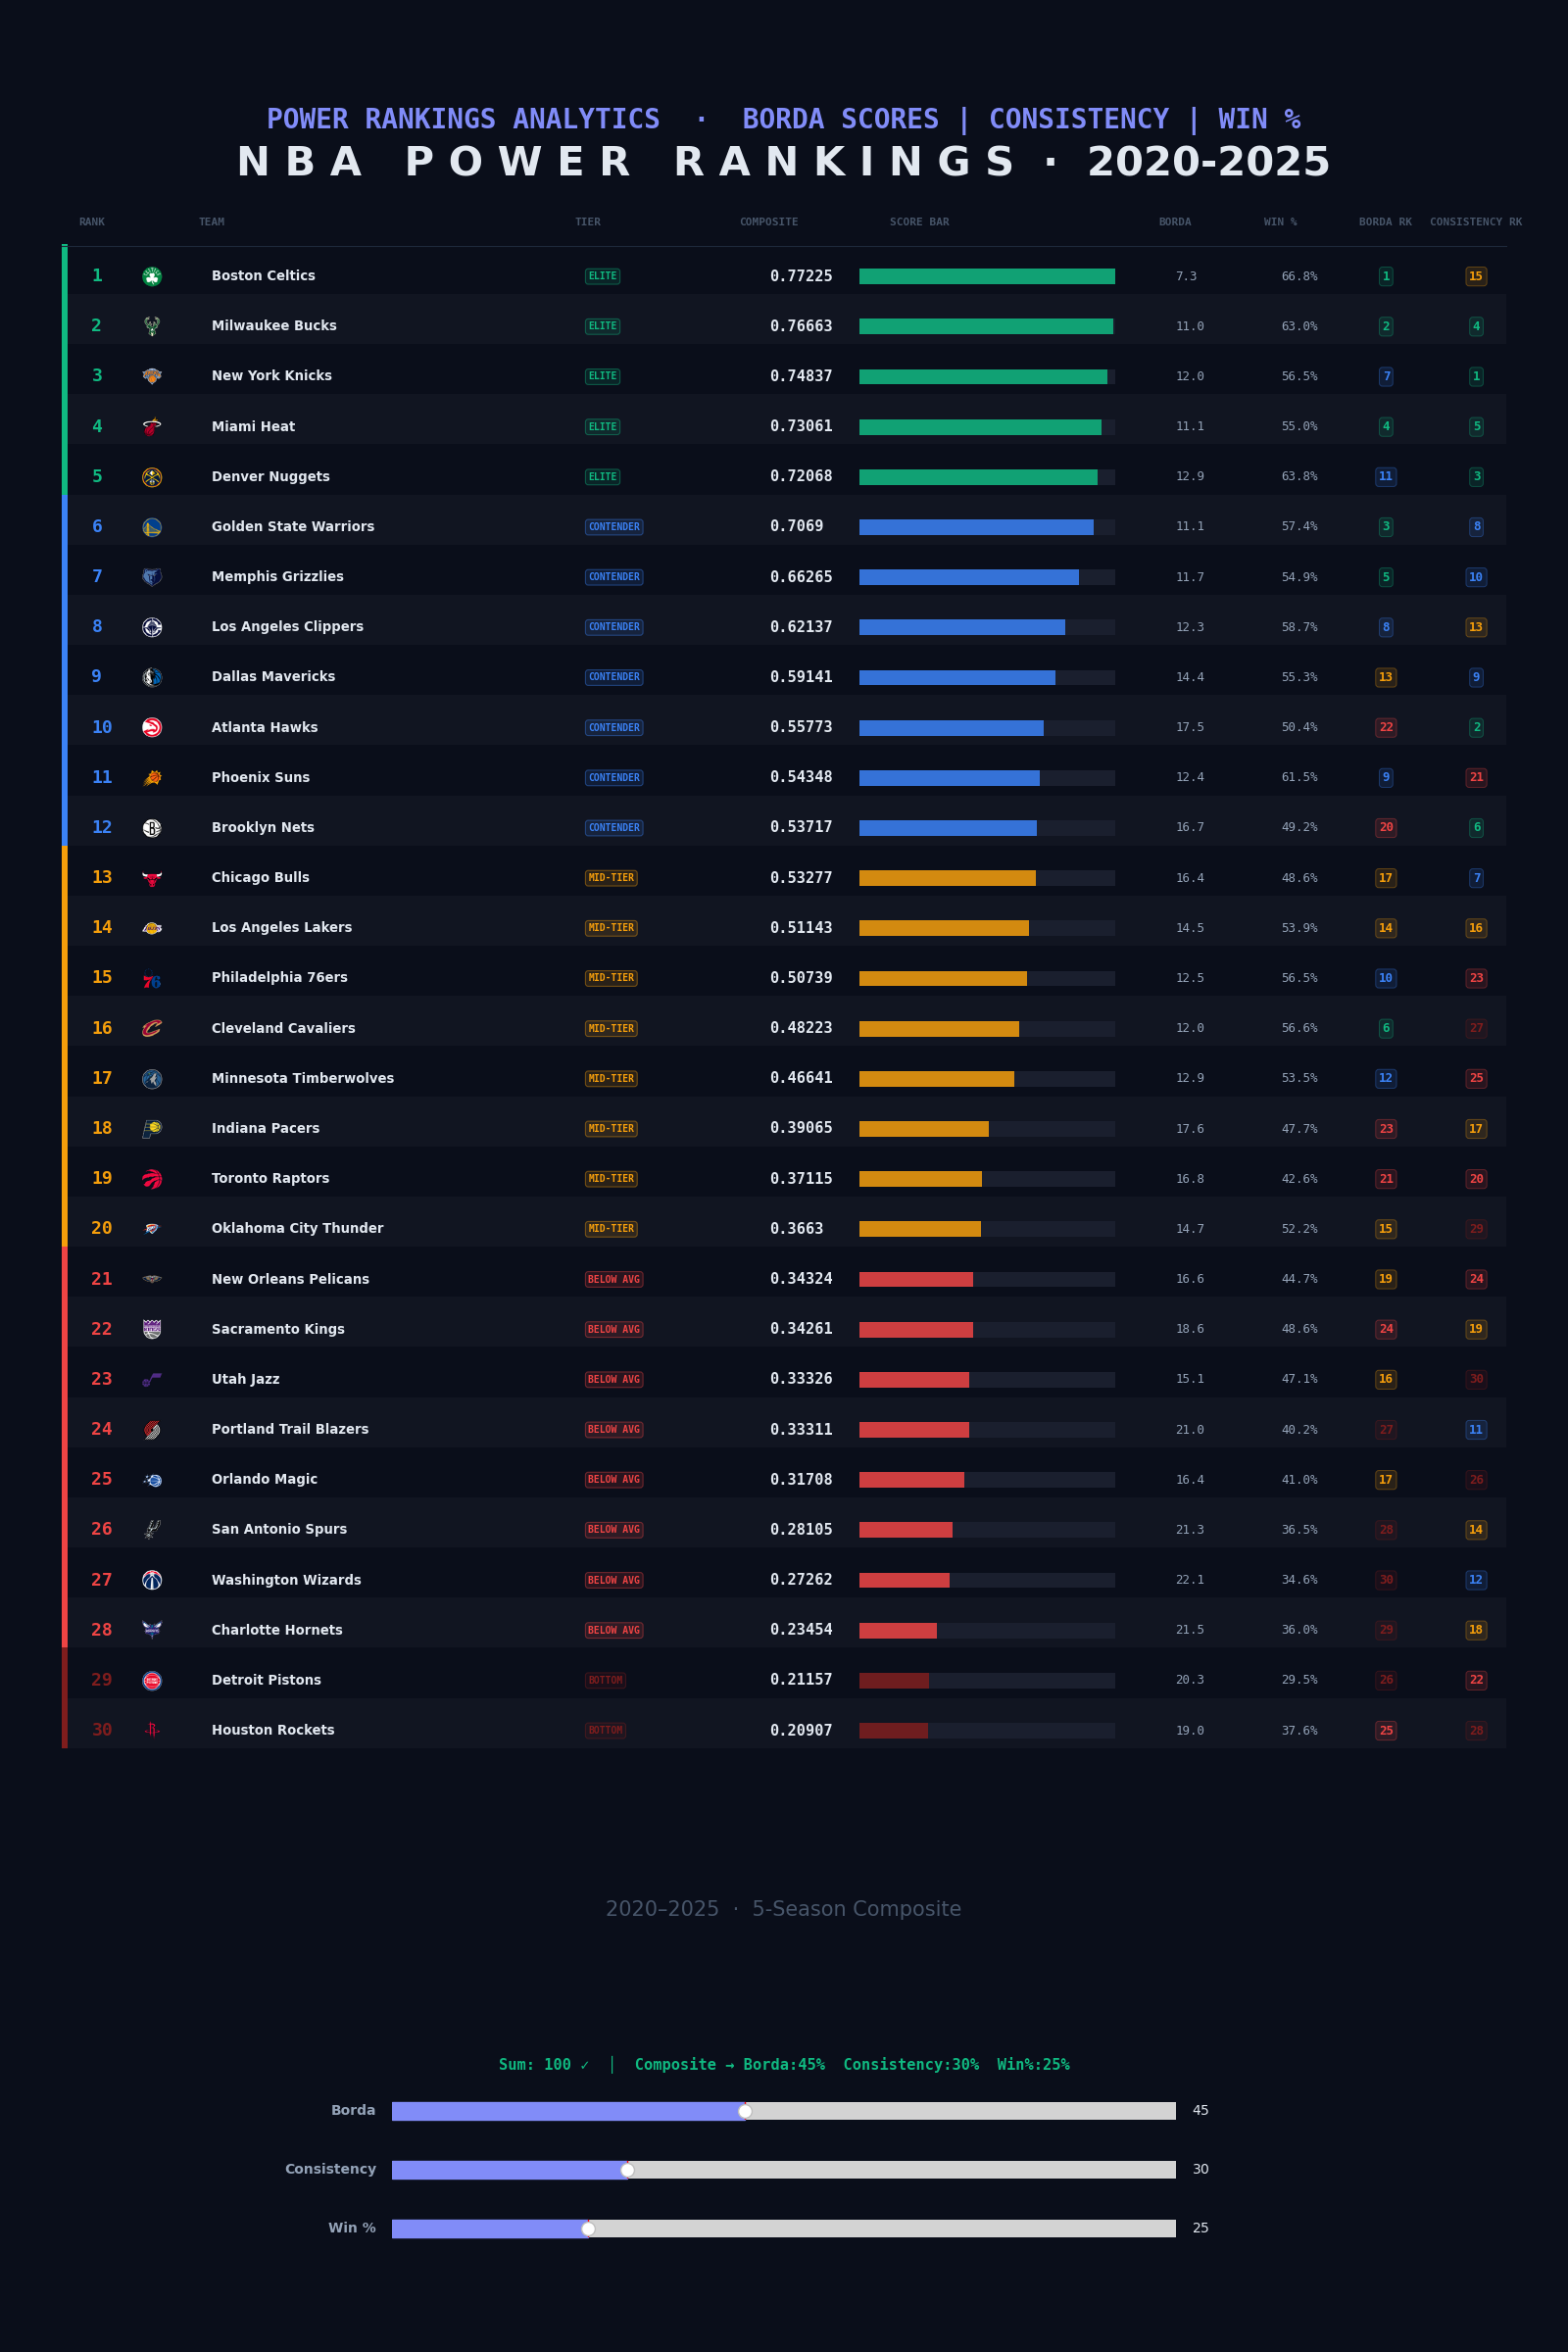

In [33]:
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
import requests
from io import BytesIO
import numpy as np
n_teams = len(df)
min_borda = df['Avg_Combined_Borda'].min()
max_borda = df['Avg_Combined_Borda'].max()
max_consist = df['Consistency_Rank'].max()
abbr_map = {
    "Atlanta Hawks": "atl",
    "Boston Celtics": "bos",
    "Brooklyn Nets": "bkn",
    "Charlotte Hornets": "cha",
    "Chicago Bulls": "chi",
    "Cleveland Cavaliers": "cle",
    "Dallas Mavericks": "dal",
    "Denver Nuggets": "den",
    "Detroit Pistons": "det",
    "Golden State Warriors": "gs",
    "Houston Rockets": "hou",
    "Indiana Pacers": "ind",
    "Los Angeles Clippers": "lac",
    "Los Angeles Lakers": "lal",
    "Memphis Grizzlies": "mem",
    "Miami Heat": "mia",
    "Milwaukee Bucks": "mil",
    "Minnesota Timberwolves": "min",
    "New Orleans Pelicans": "no",
    "New York Knicks": "ny",
    "Oklahoma City Thunder": "okc",
    "Orlando Magic": "orl",
    "Philadelphia 76ers": "phi",
    "Phoenix Suns": "phx",
    "Portland Trail Blazers": "por",
    "Sacramento Kings": "sac",
    "San Antonio Spurs": "sa",
    "Toronto Raptors": "tor",
    "Utah Jazz": "utah",
    "Washington Wizards": "wsh",}
missing = sorted(set(df["Tm"]) - set(abbr_map.keys()))
if missing:
    print("Teams in df missing from abbr_map:", missing)
team_colors = {
    "atl": "#E03A3E",
    "bos": "#007A33",
    "bkn": "#000000",
    "cha": "#1D1160",
    "chi": "#CE1141",
    "cle": "#6F263D",
    "dal": "#00538C",
    "den": "#0E2240",
    "det": "#C8102E",
    "gs":  "#1D428A",
    "hou": "#CE1141",
    "ind": "#002D62",
    "lac": "#C8102E",
    "lal": "#552583",
    "mem": "#5D76A9",
    "mia": "#98002E",
    "mil": "#00471B",
    "min": "#0C2340",
    "no":  "#0C2340",
    "ny":  "#006BB6",
    "okc": "#007AC1",
    "orl": "#0077C0",
    "phi": "#006BB6",
    "phx": "#1D1160",
    "por": "#E03A3E",
    "sac": "#5A2D81",
    "sa":  "#C4CED4",
    "tor": "#CE1141",
    "utah":"#002B5C",
    "wsh":"#002B5C",}
def fetch_logo(abbr, size=28):
    try:
        url = f"https://a.espncdn.com/combiner/i?img=/i/teamlogos/nba/500/{abbr}.png&h=80&w=80"
        resp = requests.get(url, timeout=5)
        img = Image.open(BytesIO(resp.content)).convert("RGBA").resize((size, size), Image.LANCZOS)
        return np.array(img)
    except:
        return None
print("Fetching team logos and loading visualization...")
logos = {abbr: fetch_logo(abbr) for abbr in abbr_map.values()}
def compute_composite(row, weights, season_penalty=True):
    norm_borda = 1 - (row['Avg_Combined_Borda'] - min_borda) / (max_borda - min_borda)
    norm_consist = 1 - (row['Consistency_Rank'] - 1) / (max_consist - 1)
    norm_wpct = row['Avg_W_pct'] / 100
    season_factor = min(row['Seasons_Played'] / 3, 1.0) if season_penalty else 1.0
    raw = (norm_borda * weights['borda'] +
           norm_consist * weights['consistency'] +
           norm_wpct * weights['win_pct'])
    return round(raw, 5)
def get_tier(rank, total):
    if rank <= 5:  return ('ELITE', '#10b981')
    if rank <= 12: return ('CONTENDER', '#3b82f6')
    if rank <= 20: return ('MID-TIER', '#f59e0b')
    if rank <= 28: return ('BELOW AVG', '#ef4444')
    return ('BOTTOM', '#7f1d1d')
fig = plt.figure(figsize=(16, 24))
fig.patch.set_facecolor('#0a0e1a')
ax = fig.add_axes([0.02, 0.11, 0.96, 0.82])
ax.set_facecolor('#0a0e1a')
ax.axis('off')
slider_color = '#1e293b'
active_color = '#818cf8'
ax_borda   = fig.add_axes([0.25, 0.095, 0.50, 0.015], facecolor=slider_color)
ax_consist = fig.add_axes([0.25, 0.070, 0.50, 0.015], facecolor=slider_color)
ax_wpct    = fig.add_axes([0.25, 0.045, 0.50, 0.015], facecolor=slider_color)
s_borda   = Slider(ax_borda,   'Borda',       0, 100, valinit=45, valstep=1, color=active_color)
s_consist = Slider(ax_consist, 'Consistency', 0, 100, valinit=30, valstep=1, color=active_color)
s_wpct    = Slider(ax_wpct,    'Win %',       0, 100, valinit=25, valstep=1, color=active_color)
for s in [s_borda, s_consist, s_wpct]:
    s.label.set_color('#94a3b8')
    s.label.set_fontsize(10)
    s.label.set_fontweight('bold')
    s.valtext.set_color('#e2e8f0')
    s.valtext.set_fontsize(10)
weight_text = fig.text(0.50, 0.120, '', ha='center', fontsize=11,
                       fontweight='bold', fontfamily='monospace')
def update(val=None):
    ax.clear()
    ax.set_facecolor('#0a0e1a')
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    raw_b, raw_c, raw_w = s_borda.val, s_consist.val, s_wpct.val
    total = raw_b + raw_c + raw_w
    if total == 0:
        weights = {'borda': 0.25, 'consistency': 0.25, 'win_pct': 0.25}
        total = 100
    else:
        weights = {
            'borda': raw_b / total,
            'consistency': raw_c / total,
            'win_pct': raw_w / total,}
    warn = '!' if abs(total - 100) > 0.5 else '✓'
    weight_text.set_text(
        f"Sum: {int(total)} {warn}  │  "
        f"Composite → Borda:{weights['borda']:.0%}  Consistency:{weights['consistency']:.0%}  "
        f"Win%:{weights['win_pct']:.0%}")
    weight_text.set_color('#10b981' if abs(total - 100) < 1 else '#f59e0b')
    df['Composite'] = df.apply(compute_composite, axis=1, weights=weights)
    ranked = df.sort_values('Composite', ascending=False).reset_index(drop=True)
    ranked['Power_Rank'] = range(1, n_teams + 1)
    max_comp = ranked['Composite'].max()
    row_h = 0.026
    header_y = 0.97
    start_y = header_y - 0.028
    ax.text(0.5, 1.03, 'POWER RANKINGS ANALYTICS  ·  BORDA SCORES | CONSISTENCY | WIN %', transform=ax.transAxes,
            ha='center', va='top', fontsize=20, fontweight='bold', color='#818cf8',
            fontfamily='monospace')
    ax.text(0.5, 1.01, 'N B A   P O W E R   R A N K I N G S  ·  2020-2025', transform=ax.transAxes,
            ha='center', va='top', fontsize=30, fontweight='bold', color='#e2e8f0')
    ax.text(0.5, 0.100, '2020–2025  ·  5-Season Composite',
            transform=ax.transAxes, ha='center', va='top', fontsize=15, color='#475569')
    cols = {'rank': 0.04, 'logo': 0.08, 'team': 0.12, 'tier': 0.37,
            'composite': 0.49, 'bar_start': 0.55, 'bar_end': 0.72,
            'borda': 0.76, 'wpct': 0.83, 'borda_rk': 0.90, 'consist_rk': 0.96}
    for x, label in [(cols['rank'], 'RANK'), (cols['team'], 'TEAM'), (cols['tier'], 'TIER'),
                     (cols['composite'], 'COMPOSITE'), (cols['bar_start'] + 0.04, 'SCORE BAR'),
                     (cols['borda'], 'BORDA'), (cols['wpct'], 'WIN %'),
                     (cols['borda_rk'], 'BORDA RK'), (cols['consist_rk'], 'CONSISTENCY RK')]:
        ax.text(x, header_y, label, ha='center', transform=ax.transAxes, fontsize=8,
                fontweight='bold', color='#475569', fontfamily='monospace', va='center')
    ax.plot([0.02, 0.98], [header_y - 0.012, header_y - 0.012],
            transform=ax.transAxes, color='#1e293b', linewidth=0.8)
    for i, (_, row) in enumerate(ranked.iterrows()):
        y = start_y - i * row_h
        tm = row['Tm']
        abbr = abbr_map[tm]
        tier_label, tier_color = get_tier(row['Power_Rank'], n_teams)
        if i % 2 == 1:
            r = plt.Rectangle((0.02, y - row_h/2 + 0.004), 0.96, row_h,
                               transform=ax.transAxes, facecolor='#ffffff08', edgecolor='none', zorder=0)
            ax.add_patch(r)
        a = plt.Rectangle((0.02, y - row_h/2 + 0.004), 0.004, row_h,
                           transform=ax.transAxes, facecolor=tier_color, edgecolor='none', zorder=1)
        ax.add_patch(a)
        ax.text(cols['rank'], y, str(row['Power_Rank']), transform=ax.transAxes,
                fontsize=13, fontweight='bold', color=tier_color, va='center', fontfamily='monospace')
        logo_arr = logos.get(abbr)
        if logo_arr is not None:
            im = OffsetImage(logo_arr, zoom=0.55)
            ab = AnnotationBbox(im, (cols['logo'], y), xycoords='axes fraction',
                               frameon=False, box_alignment=(0.5, 0.5))
            ax.add_artist(ab)
        ax.text(cols['team'], y, tm, transform=ax.transAxes,
                fontsize=9.5, fontweight='bold', color='#e2e8f0', va='center')
        bp = dict(boxstyle='round,pad=0.3', facecolor=tier_color + '22', edgecolor=tier_color + '66', linewidth=0.8)
        ax.text(cols['tier'], y, tier_label, transform=ax.transAxes, fontsize=7,
                fontweight='bold', color=tier_color, va='center', bbox=bp, fontfamily='monospace')
        ax.text(cols['composite'], y, f"{row['Composite']}", transform=ax.transAxes,
                fontsize=11, fontweight='bold', color='#e2e8f0', va='center', fontfamily='monospace')
        bw = (cols['bar_end'] - cols['bar_start']) * (row['Composite'] / max_comp) if max_comp > 0 else 0
        bg = plt.Rectangle((cols['bar_start'], y - 0.004), cols['bar_end'] - cols['bar_start'],
                           0.008, transform=ax.transAxes, facecolor='#1a1f2e', edgecolor='none', zorder=1)
        fl = plt.Rectangle((cols['bar_start'], y - 0.004), bw, 0.008,
                           transform=ax.transAxes, facecolor=tier_color, edgecolor='none', zorder=2, alpha=0.85)
        ax.add_patch(bg)
        ax.add_patch(fl)
        ax.text(cols['borda'], y, f"{row['Avg_Combined_Borda']:.1f}", transform=ax.transAxes,
                fontsize=9, color='#94a3b8', va='center', fontfamily='monospace')
        ax.text(cols['wpct'], y, f"{row['Avg_W_pct']:.1f}%", transform=ax.transAxes,
                fontsize=9, color='#94a3b8', va='center', fontfamily='monospace')
        for cx, v in [(cols['borda_rk'], row['Overall_Combined_Rank']),
                      (cols['consist_rk'], row['Consistency_Rank'])]:
            p = (n_teams - v) / (n_teams - 1)
            bc = '#10b981' if p > 0.8 else '#3b82f6' if p > 0.6 else '#f59e0b' if p > 0.35 else '#ef4444' if p > 0.15 else '#7f1d1d'
            bbp = dict(boxstyle='round,pad=0.25', facecolor=bc + '22', edgecolor=bc + '55', linewidth=0.7)
            ax.text(cx, y, str(int(v)), transform=ax.transAxes, fontsize=9,
                    fontweight='bold', color=bc, va='center', ha='center', bbox=bbp, fontfamily='monospace')
    fig.canvas.draw_idle()
s_borda.on_changed(update)
s_consist.on_changed(update)
s_wpct.on_changed(update)
update()
plt.show()